In [21]:
import pandas as pd
import matplotlib 
from matplotlib import pyplot as plt

all_params = pd.read_csv("./all_params.csv", index_col="idx")
mle_estimates = pd.read_csv("./mle_results/mle_estimates.csv", index_col="tree_idx")
deep_estimates = pd.read_csv("./parameter_estimates/all_estimates.csv", index_col="tree_idx")


In [22]:
mle_estimates.head()

,n_tips,true_R0,true_mu,true_lambda,mle_R0,mle_mu,mle_lambda
tree_idx,,,,,,,
0,285,1.43571,3.57143,5.127538,2.00000,4.037211,8.074423
1,320,2.39145,3.28947,7.866603,2.00000,5.000000,10.000000
10,463,2.79359,3.55872,9.941605,2.00000,5.000000,10.000000
100,102,1.08429,1.42857,1.548984,1.19946,0.585598,0.702401
1000,378,1.37956,2.43309,3.356594,2.00000,5.000000,10.000000


In [32]:
model_comparison = pd.merge(
    mle_estimates,
    deep_estimates[["R_naught", "Infectious_period"]]
, left_index=True, right_index=True, how="outer").reset_index().rename(columns={"R_naught": "deep_R0"})

model_comparison.head()



,tree_idx,n_tips,true_R0,true_mu,true_lambda,mle_R0,mle_mu,mle_lambda,deep_R0,Infectious_period
0,0,285,1.43571,3.57143,5.127538,2.0,4.037211,8.074423,1.463040,3.622692
1,1,320,2.39145,3.28947,7.866603,2.0,5.000000,10.000000,2.094788,3.128354
2,2,187,2.04427,2.60417,5.323627,2.0,5.000000,10.000000,2.612961,3.219929
3,3,491,2.48013,3.31126,8.212355,2.0,5.000000,10.000000,2.413860,3.308560
4,4,286,1.65982,2.28311,3.789552,2.0,5.000000,10.000000,1.477111,1.965546


In [40]:
long_data = model_comparison.melt(id_vars=["tree_idx", "n_tips", "true_R0"], 
                      value_vars=["mle_R0", "deep_R0"],
                      var_name="model",
                      value_name="R0_estimate")

long_data["bias"] = long_data["true_R0"] - long_data["R0_estimate"]
long_data.head()

,tree_idx,n_tips,true_R0,model,R0_estimate,bias
0,0,285,1.43571,mle_R0,2.0,-0.56429
1,1,320,2.39145,mle_R0,2.0,0.39145
2,2,187,2.04427,mle_R0,2.0,0.04427
3,3,491,2.48013,mle_R0,2.0,0.48013
4,4,286,1.65982,mle_R0,2.0,-0.34018


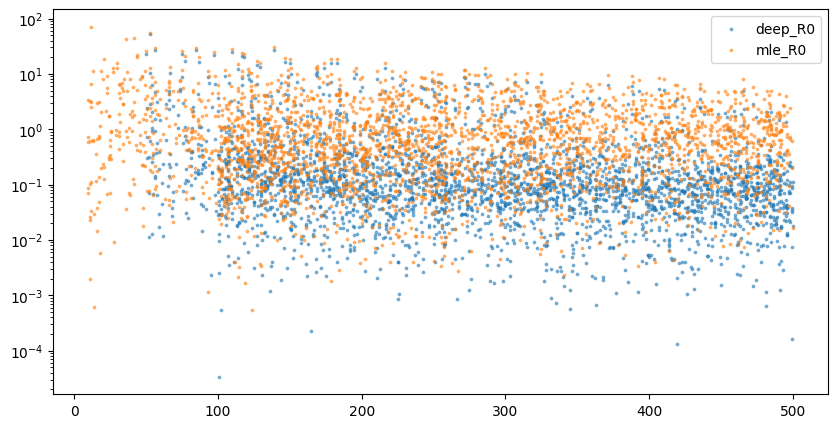

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))

for type, group in long_data.groupby("model"):
    ax.scatter(group["n_tips"], group["bias"], label=type, alpha=0.5, s=3)
    
ax.set_yscale("log")
ax.legend()